In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['aabheer', 'aadarsh', 'aadesh', 'aadhira', 'aadi']

In [3]:
len(words)

6555

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s,i in stoi.items()}

In [7]:
# building the dataset
def build_dataset(words):
  block_size = 3
  X, Y = [], []

  for w in words:
    context = [0]*block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # 0 -> n1
Xdev, Ydev = build_dataset(words[n1:n2]) # n1 -> n2
Xte, Yte = build_dataset(words[n2:]) # n2 -> len(words)

In [8]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([42207, 3]), torch.int64, torch.Size([42207]), torch.int64)

In [53]:
n_embd = 10
block_size = 3
n_hidden = 200
vocab_size = 27

# Model
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, 10), generator=g)
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3)/(30**0.5) # =0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size), generator=g) * 0.01 # loss will not be hockey shaped if we multiply by 0
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, W2, b2, b1]

In [54]:
sum(p.nelement() for p in parameters)

11897

In [55]:
for p in parameters:
  p.requires_grad = True

In [56]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [57]:
lri = []
lossi = []
stepi = []

In [65]:
max_steps = 30000
progress = ''
for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (36,), generator=g)

  #forward pass
  emb = C[Xtr[ix]] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  #linear layer
  hpreact = embcat @ W1 + b1
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])
  # print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  #update
  # lr = lrs[i]
  # lr = 0.01    # 0.11 --> 0.01 => learning rate decay in late stages of training
  lr = 0.11 if i < 10000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track statss
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

  if i % 5000 == 0:
    print(f'loss[{i}/{max_steps}]: {loss.item():.4f}')

# print(loss.item())

loss[0/30000]: 1.9357
loss[5000/30000]: 1.8944
loss[10000/30000]: 2.0168
loss[15000/30000]: 1.6368
loss[20000/30000]: 1.9041
loss[25000/30000]: 2.2237


In [66]:
print(loss.item())

1.8931236267089844


In [67]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
      'train': (Xtr, Ytr),
      'val': (Xdev, Ydev),
      'test' : (Xte, Yte),
  }[split]

  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)

  hpreact = embcat @ W1 +b1
  h = torch.tanh(hpreact)
  logits = h@W2+b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7890937328338623
val 1.9696332216262817


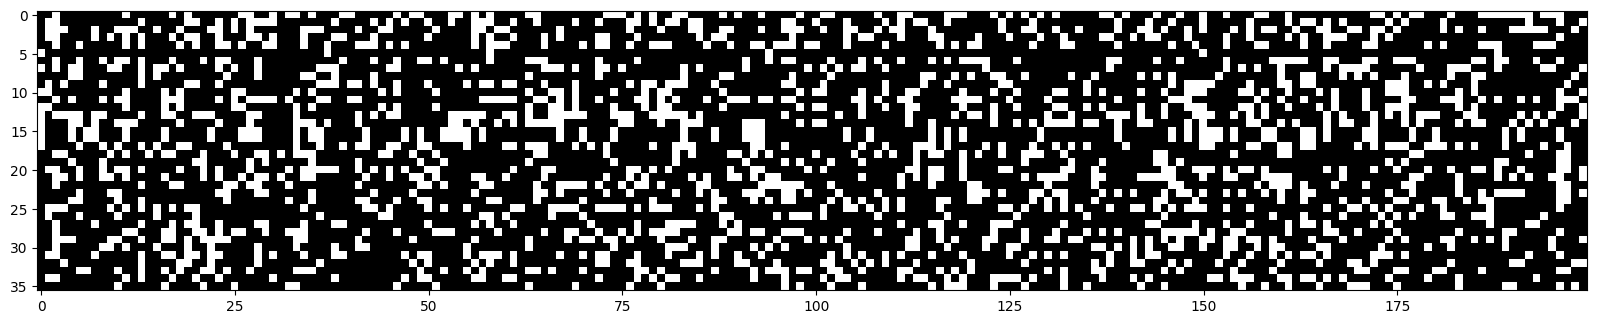

In [68]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')
# # white = True, black = False
# entirely white column = dead neuron cuz grad will equal to zero then

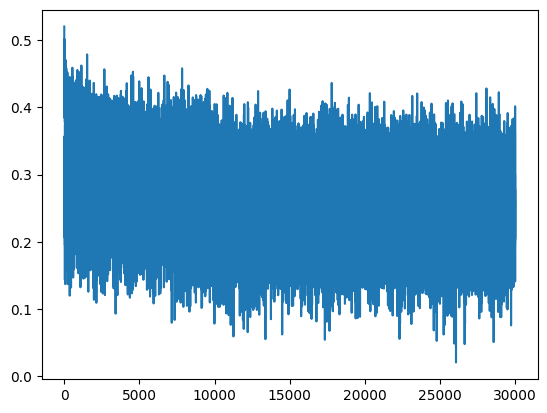

In [69]:
plt.plot(stepi, lossi)

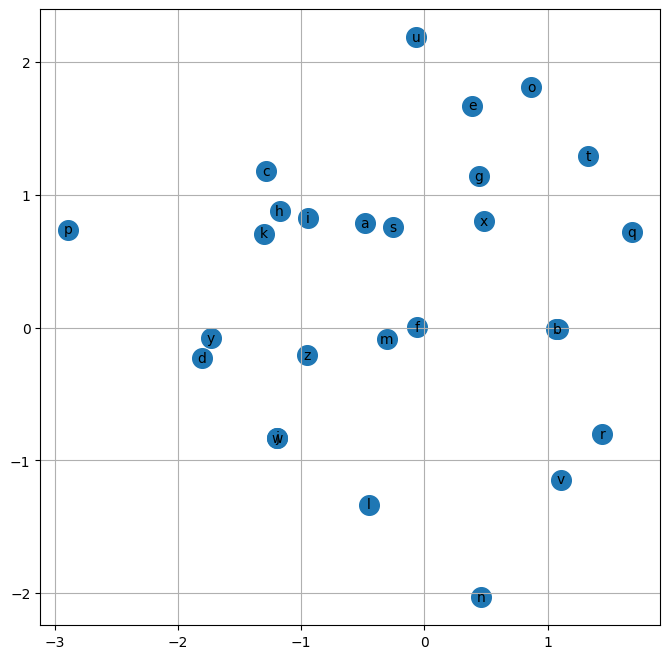

In [70]:
# visulizing dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va="center")
plt.grid('minor')

In [71]:
# sample from the model
block_size = 3
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
  out = []
  context = [0] * block_size # initializing with ...
  while True:
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1, -1) @ W1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

dev.
malomal.
sarvagita.
krit.
mrittamohakash.
kandrabhagyap.
padhrughosh.
molika.
kausik.
teda.
kali.
kamsiddhankavi.
nilaslsh.
hilidevvtahlav.
dhyu.
dev.
jil.
puni.
ishna.
bridyik.


In [72]:
import pickle
pickle.dump(W1, open('W1.pkl', 'wb'))
pickle.dump(b1, open('b1.pkl', 'wb'))
pickle.dump(W2, open('W2.pkl', 'wb'))
pickle.dump(b2, open('b2.pkl', 'wb'))